# TP2 — Exploration du corpus CAMille de 1939

**Étudiante : Doha Belaaroussi**

Ce notebook analyse 100 fichiers du corpus CAMille publiés en 1939. Il combine quatre traitements présentés dans le module 3 : l’extraction de mots-clés avec YAKE, la création d’un nuage de mots, la reconnaissance d’entités nommées avec SpaCy et l’analyse de sentiment avec TextBlob-FR.

## Choix de l’année

L’année 1939 a été retenue en raison de son contexte politique particulier, marqué par les tensions internationales et le début de la Seconde Guerre mondiale. Ce choix permet d’examiner la présence de ce contexte dans la presse belge, tout en tenant compte des autres contenus présents dans les pages, notamment les annonces, les programmes culturels et les informations locales.

# 1. Extraction des mots-clés

## Imports

In [1]:
import os
import yake
import pandas as pd

## Extraire les mots clés d'un document avec Yake

https://github.com/LIAAD/yake

In [2]:
# Instantier l'extracteur de mots clés
kw_extractor = yake.KeywordExtractor(lan="fr", top=50)
kw_extractor

In [3]:
data_path = "../../data/txt/"

files = sorted(
    f for f in os.listdir(data_path)
    if f.endswith(".txt") and "_1939-" in f
)

In [4]:
# Imprimer le nombre de fichiers identifiés
len(files)

100

In [5]:
# Les dix premiers fichiers
files[:10]

['KB_JB838_1939-01-02_01-00009.txt',
 'KB_JB838_1939-01-05_01-00008.txt',
 'KB_JB838_1939-01-05_01-00014.txt',
 'KB_JB838_1939-01-06_01-00005.txt',
 'KB_JB838_1939-01-07_01-00006.txt',
 'KB_JB838_1939-01-08_01-00010.txt',
 'KB_JB838_1939-01-10_01-00011.txt',
 'KB_JB838_1939-01-19_01-00010.txt',
 'KB_JB838_1939-01-21_01-00002.txt',
 'KB_JB838_1939-01-24_01-00014.txt']

In [6]:
# Choisir un fichier
this_file = files[0]
this_file

'KB_JB838_1939-01-02_01-00009.txt'

In [7]:
# Récupérer le texte du fichier
text = open(os.path.join(data_path, this_file), 'r', encoding='utf-8').read()
text[:500]

'■ 2, et 3 JANyiÉR 1 9 •JJ iy-^ tJT» v\'.^- -..\'. *;rV| y#»- **••»*■\'» V».. \'’.^V\'\' \'.“ ,. f. * >/. * v* •■\'. •; * .• "ï..-.\'.\'rv. w->*v.v. :~r-:.*. ■\'S.XZ-:EQOLE\'sp^cIftllBéo\'dé** v,-". \'.v onnu«vmtiR-. iESOIR v,*ffàÿl«ïE*r é.\'. • w -1\' Wf^^XX‘% ] XXM | ït ; PEDICURIE Maurice i WAFELLMAN ^complète\',, tüÿorle ,*t pfàtiç, 6i*i> Mtàoota. ÿt|.-. 87.S5.gO. /. 33403 B TOUSSER SANS; ARRÊT est extrêmement cnnuÿeux et douloureux par le fait que Vous êtes .tétine t).des rapports verbaux\'continuels avec là-'

In [8]:
# Extraire les mots clés de ce texte
keywords = kw_extractor.extract_keywords(text)
keywords

[('rue', np.float64(0.003025710506643931)),
 ('MAISON', np.float64(0.006428351783863918)),
 ('LOUER', np.float64(0.006549183411937853)),
 ('Tél', np.float64(0.008174740694569855)),
 ('BRUXELLES', np.float64(0.00920149907586921)),
 ('Ghislaine', np.float64(0.012897215071125338)),
 ('vendre', np.float64(0.01380185048915708)),
 ('rue Royale', np.float64(0.01623312409455591)),
 ('prix', np.float64(0.017964022211695022)),
 ('Brux', np.float64(0.01829039541288025)),
 ('belle maison', np.float64(0.02182303084057196)),
 ('Belle maison jardin', np.float64(0.02364729635856836)),
 ('Cours', np.float64(0.025022079035631806)),
 ('Désire louer Bruxelles', np.float64(0.02559043234128406)),
 ('Rossel', np.float64(0.02649913576339132)),
 ('avenue', np.float64(0.02717675888535889)),
 ('Rapport', np.float64(0.028289779290236235)),
 ('Jardin', np.float64(0.028521020123520764)),
 ('Moniteur Belge', np.float64(0.0291594539605325)),
 ('LOUER petite maison', np.float64(0.029536571612591593)),
 ('LOUER RUE', n

In [9]:
# Ne garder que les bigrammes
kept = []
for kw, score in keywords:
    words = kw.split()
    if len(words) == 2:
        kept.append(kw)
kept

['rue Royale',
 'belle maison',
 'Moniteur Belge',
 'LOUER RUE',
 'LOUER maison',
 'louer Bruxelles',
 'rue Van',
 'maison jardin']

## Faire la même opération sur tous les documents

In [10]:
keyword_rows = []

for filename in files:
    file_path = os.path.join(data_path, filename)

    with open(file_path, "r", encoding="utf-8") as file:
        document_text = file.read()

    document_keywords = kw_extractor.extract_keywords(document_text)

    for keyword, score in document_keywords:
        normalized_keyword = " ".join(keyword.lower().split())

        if len(normalized_keyword.split()) == 2:
            keyword_rows.append({
                "fichier": filename,
                "mot_cle": normalized_keyword,
                "score_yake": float(score)
            })

keywords_df = pd.DataFrame(keyword_rows)

print("Documents analysés :", len(files))
print("Bigrammes retenus :", len(keywords_df))
keywords_df.head(10)

Documents analysés : 100
Bigrammes retenus : 951


,fichier,mot_cle,score_yake
0,KB_JB838_1939-01-02_01-00009.txt,rue royale,0.016233
1,KB_JB838_1939-01-02_01-00009.txt,belle maison,0.021823
2,KB_JB838_1939-01-02_01-00009.txt,moniteur belge,0.029159
3,KB_JB838_1939-01-02_01-00009.txt,louer rue,0.030319
4,KB_JB838_1939-01-02_01-00009.txt,louer maison,0.034088
5,KB_JB838_1939-01-02_01-00009.txt,louer bruxelles,0.035378
6,KB_JB838_1939-01-02_01-00009.txt,rue van,0.045847
7,KB_JB838_1939-01-02_01-00009.txt,maison jardin,0.062120
8,KB_JB838_1939-01-05_01-00008.txt,janvier mars,0.003294
9,KB_JB838_1939-01-05_01-00008.txt,lesoir commercé,0.004787


In [11]:
keyword_summary = (
    keywords_df
    .groupby("mot_cle")
    .agg(
        nb_documents=("fichier", "nunique"),
        nb_occurrences=("mot_cle", "size"),
        score_yake_moyen=("score_yake", "mean"),
        meilleur_score_yake=("score_yake", "min")
    )
    .reset_index()
    .sort_values(
        by=["nb_documents", "nb_occurrences", "score_yake_moyen"],
        ascending=[False, False, True]
    )
)

keyword_summary.head(30)

,mot_cle,nb_documents,nb_occurrences,score_yake_moyen,meilleur_score_yake
15,agence rossel,26,26,0.017867,0.001290
199,ecrire agence,13,13,0.029759,0.005255
12,affaires étrangères,11,11,0.031533,0.006658
516,programme varié,10,10,0.001680,0.001206
120,concert varié,10,10,0.006488,0.002276
307,journal parlé,9,9,0.013508,0.007062
559,rue van,9,9,0.045557,0.008599
558,rue royale,9,9,0.047090,0.015169
96,cherche place,8,8,0.024325,0.006072
296,jeune fille,8,8,0.032254,0.009066


## Première analyse des mots-clés

L’analyse porte sur 100 fichiers publiés en 1939. YAKE a permis de retenir 951 occurrences de bigrammes. Le classement brut est principalement dominé par des expressions issues des petites annonces, notamment « agence Rossel », « écrire agence », « cherche place » et « belle maison ». Les programmes culturels et radiophoniques apparaissent également à travers « programme varié », « concert varié » et « journal parlé ». Certains bigrammes relèvent plus directement de l’actualité politique, comme « affaires étrangères » et « gouvernement britannique ».

Ces résultats montrent que le sous-corpus de 1939 ne contient pas uniquement des articles d’actualité, mais aussi des annonces et des programmes. Ils mettent également en évidence les effets de l’OCR, notamment avec la coexistence des formes « jeune fille » et « jne fille ». Ces éléments répétitifs et ces erreurs peuvent influencer le classement des mots-clés. Un nettoyage supplémentaire est donc nécessaire avant de construire le nuage de mots et d’interpréter les thèmes dominants de l’année.

# Nuage de mots du sous-corpus de 1939

Cette partie regroupe le contenu des 100 fichiers de 1939, nettoie les textes et étudie les fréquences lexicales. Une première version est produite avec les mots vides français, puis la liste d’exclusion est enrichie à partir des éléments répétitifs et des erreurs observés dans le corpus.

In [12]:
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

nltk.download("stopwords", quiet=True)

True

In [13]:
content_list = []

for filename in files:
    file_path = os.path.join(data_path, filename)

    with open(file_path, "r", encoding="utf-8") as file:
        content_list.append(file.read())

all_text = " ".join(content_list)

print("Documents réunis :", len(content_list))
print("Nombre de caractères :", len(all_text))

Documents réunis : 100
Nombre de caractères : 4073198


In [14]:
stopwords_initial = set(stopwords.words("french"))

tokens_initial = [
    word.lower()
    for word in nltk.wordpunct_tokenize(all_text)
    if len(word) > 2
    and word.isalpha()
    and word.lower() not in stopwords_initial
]

frequencies_initial = Counter(tokens_initial)

print("Nombre de mots conservés :", len(tokens_initial))
frequencies_initial.most_common(30)

Nombre de mots conservés : 361296


[('rue', 2591),
 ('dem', 1456),
 ('rossel', 1370),
 ('plus', 1320),
 ('bruxelles', 1218),
 ('tout', 1018),
 ('tél', 1014),
 ('prix', 1003),
 ('van', 824),
 ('deux', 812),
 ('ans', 735),
 ('maison', 730),
 ('cette', 728),
 ('bien', 708),
 ('ecr', 708),
 ('après', 695),
 ('sous', 642),
 ('très', 640),
 ('tous', 637),
 ('bon', 632),
 ('sans', 607),
 ('place', 605),
 ('ecrire', 598),
 ('fait', 592),
 ('être', 571),
 ('faire', 558),
 ('comme', 538),
 ('louer', 527),
 ('francs', 504),
 ('heures', 492)]

In [15]:
stopwords_grammaticaux = {
    "plus", "tout", "deux", "cette", "bien", "après", "sous",
    "très", "tous", "sans", "fait", "être", "faire", "comme"
}

stopwords_editoriaux = {
    "rue", "dem", "rossel", "tél", "van", "ecr", "ecrire"
}

stopwords_enrichis = (
    stopwords_initial
    | stopwords_grammaticaux
    | stopwords_editoriaux
)

tokens_nettoyes = [
    word.lower()
    for word in nltk.wordpunct_tokenize(all_text)
    if len(word) > 2
    and word.isalpha()
    and word.lower() not in stopwords_enrichis
]

frequences_nettoyees = Counter(tokens_nettoyes)

print("Nombre de mots conservés après enrichissement :", len(tokens_nettoyes))
frequences_nettoyees.most_common(30)

Nombre de mots conservés après enrichissement : 342669


[('bruxelles', 1218),
 ('prix', 1003),
 ('ans', 735),
 ('maison', 730),
 ('bon', 632),
 ('place', 605),
 ('louer', 527),
 ('francs', 504),
 ('heures', 492),
 ('cours', 486),
 ('contre', 482),
 ('app', 472),
 ('non', 466),
 ('anvers', 465),
 ('mois', 449),
 ('grand', 445),
 ('dont', 444),
 ('disques', 441),
 ('jour', 434),
 ('mod', 429),
 ('pays', 425),
 ('conf', 423),
 ('brux', 419),
 ('agence', 415),
 ('entre', 414),
 ('part', 401),
 ('paris', 399),
 ('nord', 388),
 ('état', 387),
 ('gouvernement', 385)]

In [16]:
stopwords_seconde_iteration = {
    "contre", "non", "dont", "entre", "bon", "grand", "part",
    "ans", "mois", "heures", "jour",
    "app", "mod", "conf", "brux", "agence"
}

stopwords_finaux = stopwords_enrichis | stopwords_seconde_iteration

tokens_finaux = [
    word.lower()
    for word in nltk.wordpunct_tokenize(all_text)
    if len(word) > 2
    and word.isalpha()
    and word.lower() not in stopwords_finaux
]

frequences_finales = Counter(tokens_finaux)

print("Nombre de mots conservés après la seconde itération :", len(tokens_finaux))
frequences_finales.most_common(30)

Nombre de mots conservés après la seconde itération : 335117


[('bruxelles', 1218),
 ('prix', 1003),
 ('maison', 730),
 ('place', 605),
 ('louer', 527),
 ('francs', 504),
 ('cours', 486),
 ('anvers', 465),
 ('disques', 441),
 ('pays', 425),
 ('paris', 399),
 ('nord', 388),
 ('état', 387),
 ('gouvernement', 385),
 ('grande', 383),
 ('londres', 373),
 ('culs', 372),
 ('etc', 368),
 ('janvier', 364),
 ('avril', 363),
 ('belgique', 360),
 ('eau', 360),
 ('avenue', 357),
 ('bonne', 354),
 ('encore', 349),
 ('septembre', 344),
 ('midi', 343),
 ('soir', 339),
 ('concert', 338),
 ('belge', 337)]

In [17]:
stopwords_derniere_iteration = {
    "culs", "etc", "grande", "bonne", "encore", "avenue", "midi", "soir",
    "janvier", "février", "mars", "avril", "mai", "juin",
    "juillet", "août", "septembre", "octobre", "novembre", "décembre"
}

stopwords_finaux = stopwords_finaux | stopwords_derniere_iteration

tokens_finaux = [
    word.lower()
    for word in nltk.wordpunct_tokenize(all_text)
    if len(word) > 2
    and word.isalpha()
    and word.lower() not in stopwords_finaux
]

frequences_finales = Counter(tokens_finaux)

print("Nombre final de mots conservés :", len(tokens_finaux))
frequences_finales.most_common(30)

Nombre final de mots conservés : 329071


[('bruxelles', 1218),
 ('prix', 1003),
 ('maison', 730),
 ('place', 605),
 ('louer', 527),
 ('francs', 504),
 ('cours', 486),
 ('anvers', 465),
 ('disques', 441),
 ('pays', 425),
 ('paris', 399),
 ('nord', 388),
 ('état', 387),
 ('gouvernement', 385),
 ('londres', 373),
 ('belgique', 360),
 ('eau', 360),
 ('concert', 338),
 ('belge', 337),
 ('peut', 334),
 ('vend', 334),
 ('guerre', 334),
 ('autre', 327),
 ('dit', 319),
 ('programme', 318),
 ('cherche', 315),
 ('varié', 311),
 ('avoir', 310),
 ('toute', 309),
 ('france', 304)]

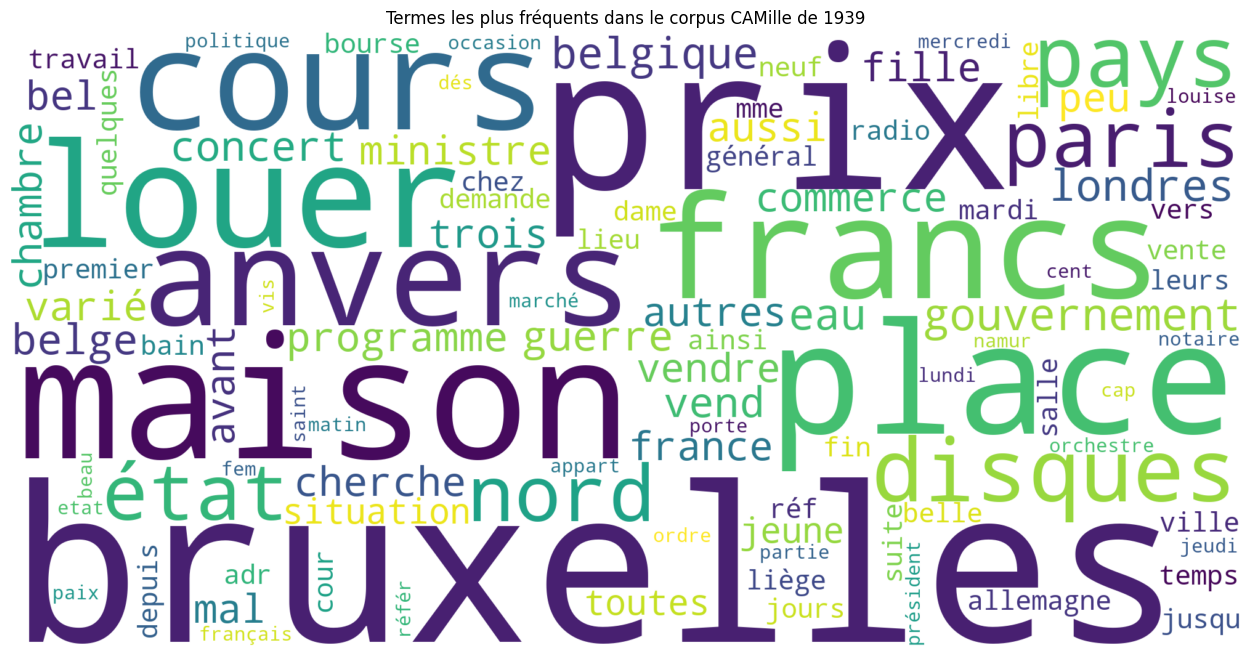

Image enregistrée : nuage_mots_1939.png


In [18]:
stopwords_finaux.update({
    "peut", "autre", "dit", "avoir", "toute"
})

tokens_finaux = [
    word.lower()
    for word in nltk.wordpunct_tokenize(all_text)
    if len(word) > 2
    and word.isalpha()
    and word.lower() not in stopwords_finaux
]

frequences_finales = Counter(tokens_finaux)

nuage_1939 = WordCloud(
    width=2000,
    height=1000,
    background_color="white",
    max_words=100,
    collocations=False,
    random_state=42
).generate_from_frequencies(frequences_finales)

image_path = "nuage_mots_1939.png"
nuage_1939.to_file(image_path)

plt.figure(figsize=(16, 8))
plt.imshow(nuage_1939, interpolation="bilinear")
plt.axis("off")
plt.title("Termes les plus fréquents dans le corpus CAMille de 1939")
plt.show()

print("Image enregistrée :", image_path)

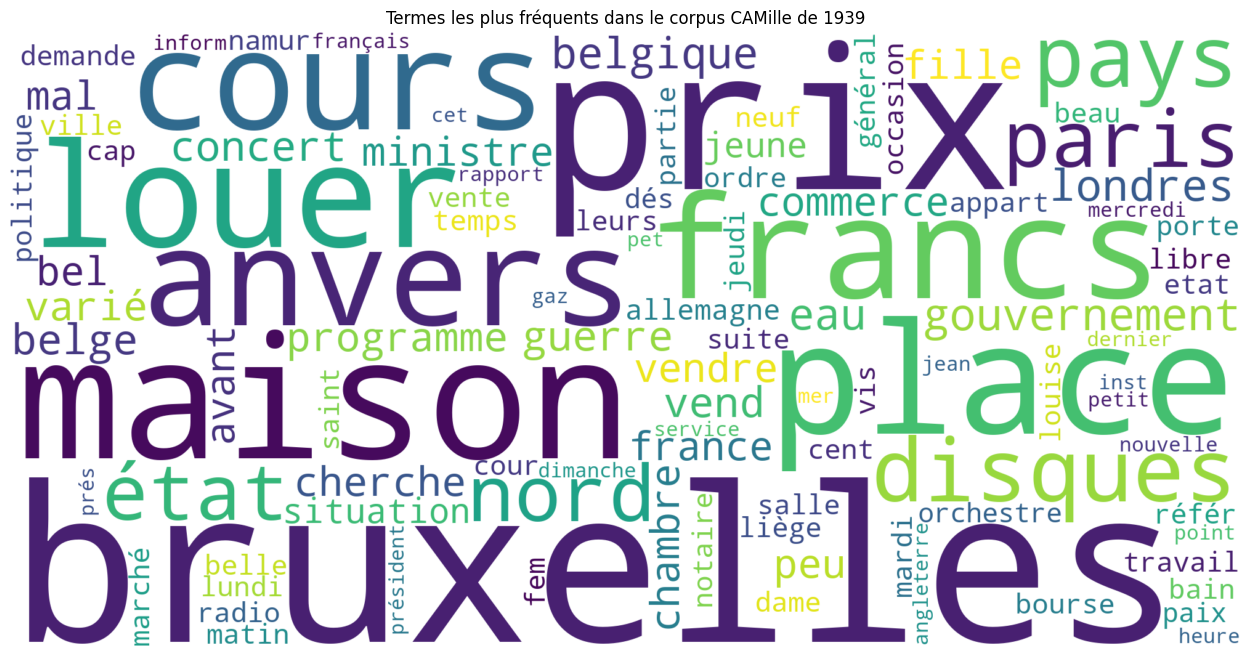

Image finale enregistrée : nuage_mots_1939.png


In [19]:
stopwords_validation_visuelle = {
    "autres", "aussi", "trois", "ainsi", "jusqu", "jusque",
    "depuis", "toutes", "jours", "puis", "vers", "chez",
    "quelques", "premier", "fin", "lieu", "nombre",
    "mme", "réf", "adr"
}

stopwords_finaux.update(stopwords_validation_visuelle)

tokens_finaux = [
    word.lower()
    for word in nltk.wordpunct_tokenize(all_text)
    if len(word) > 2
    and word.isalpha()
    and word.lower() not in stopwords_finaux
]

frequences_finales = Counter(tokens_finaux)

nuage_1939 = WordCloud(
    width=2000,
    height=1000,
    background_color="white",
    max_words=100,
    collocations=False,
    random_state=42
).generate_from_frequencies(frequences_finales)

nuage_1939.to_file("nuage_mots_1939.png")

plt.figure(figsize=(16, 8))
plt.imshow(nuage_1939, interpolation="bilinear")
plt.axis("off")
plt.title("Termes les plus fréquents dans le corpus CAMille de 1939")
plt.show()

print("Image finale enregistrée : nuage_mots_1939.png")

## Interprétation du nuage de mots

Le nuage final confirme la forte présence des petites annonces dans le sous-corpus de 1939. Les termes « prix » (1 003 occurrences), « maison » (730), « place » (605), « louer » (527) et « francs » (504) renvoient principalement aux ventes, aux locations et aux offres d’emploi. Le mot « place » reste toutefois ambigu, puisqu’il peut désigner un emploi, un lieu ou un espace public selon le contexte.

Une seconde composante concerne les lieux et l’actualité politique. Bruxelles est le terme le plus fréquent après nettoyage, avec 1 218 occurrences. Anvers, Paris, Londres, la Belgique et la France sont également visibles. Les mots « État » (387), « gouvernement » (385) et « guerre » (334) correspondent davantage au contexte politique et international de 1939.

Enfin, les termes « disques » (441), « concert » (338), « programme », « radio » et « orchestre » signalent la présence de programmes culturels et radiophoniques. Le sous-corpus associe donc plusieurs types de contenu : actualité politique, annonces commerciales et informations culturelles.

Le nettoyage a réduit le poids des mots grammaticaux, des coordonnées répétitives et de plusieurs erreurs d’OCR. Il ne supprime cependant pas toutes les ambiguïtés. Par exemple, le sens de « cours » ne peut pas être déterminé à partir de sa seule fréquence. L’interprétation du nuage doit donc être complétée par l’examen des contextes et par la reconnaissance des entités nommées.

# Reconnaissance des entités nommées

Cette partie utilise le modèle français `fr_core_news_md` de SpaCy pour repérer les personnes, les organisations et les lieux dans les 100 documents de 1939. Les résultats sont regroupés selon leur fréquence et selon le nombre de documents dans lesquels chaque entité apparaît. Cette double mesure évite de confondre une entité répétée plusieurs fois dans une seule page avec une entité présente dans l’ensemble du sous-corpus.

In [20]:
from collections import Counter, defaultdict
import spacy

nlp = spacy.load("fr_core_news_md")

print("Modèle chargé :", nlp.meta["name"])
print("Composants actifs :", nlp.pipe_names)

Modèle chargé : core_news_md
Composants actifs : ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [21]:
personnes = defaultdict(int)
organisations = defaultdict(int)
lieux = defaultdict(int)

for numero, texte_document in enumerate(content_list, start=1):
    doc = nlp(texte_document)

    for entite in doc.ents:
        texte_entite = " ".join(entite.text.split())

        if len(texte_entite) > 3:
            if entite.label_ == "PER":
                personnes[texte_entite] += 1
            elif entite.label_ == "ORG":
                organisations[texte_entite] += 1
            elif entite.label_ == "LOC":
                lieux[texte_entite] += 1

    if numero % 10 == 0:
        print(f"{numero}/100 documents traités")

print("Reconnaissance terminée.")

10/100 documents traités
20/100 documents traités
30/100 documents traités
40/100 documents traités
50/100 documents traités
60/100 documents traités
70/100 documents traités
80/100 documents traités
90/100 documents traités
100/100 documents traités
Reconnaissance terminée.


In [22]:
personnes_triees = sorted(
    personnes.items(),
    key=lambda element: element[1],
    reverse=True
)

organisations_triees = sorted(
    organisations.items(),
    key=lambda element: element[1],
    reverse=True
)

lieux_tries = sorted(
    lieux.items(),
    key=lambda element: element[1],
    reverse=True
)

print("PERSONNES LES PLUS FRÉQUENTES")
for personne, frequence in personnes_triees[:20]:
    print(f"{personne} : {frequence}")

print("\nORGANISATIONS LES PLUS FRÉQUENTES")
for organisation, frequence in organisations_triees[:20]:
    print(f"{organisation} : {frequence}")

print("\nLIEUX LES PLUS FRÉQUENTS")
for lieu, frequence in lieux_tries[:20]:
    print(f"{lieu} : {frequence}")

PERSONNES LES PLUS FRÉQUENTES
Rossel : 907
Ecrire Ag : 122
culs : 121
Louise : 93
Agence Rossel : 69
Führer : 62
Terry : 61
Chron : 46
Disques : 41
trav : 40
Hitler : 38
chamb : 36
embarq : 34
I. N. : 34
Brugmann : 31
I. N. R. : 31
M. Chamberlain : 31
Belg : 29
Monsieur : 29
François : 28

ORGANISATIONS LES PLUS FRÉQUENTES
Disques : 202
Inform : 202
Havas : 134
K ON DEM : 88
Reuter : 71
Chambre : 65
Reich : 61
Inst : 58
b. Inst : 49
Téléphone : 45
Conseil : 43
trav : 41
Chevrolet : 38
Orchestre : 37
Ford : 36
exlg : 36
Shell : 34
Sénat : 34
United Press : 34
Parlement : 26

LIEUX LES PLUS FRÉQUENTS
Bruxelles : 625
Anvers : 280
Brux : 253
Allemagne : 247
Paris : 233
Belgique : 213
Londres : 207
Liège : 151
Angleterre : 146
Etat : 116
Téléph : 103
Gand : 101
Nord : 100
Berlin : 100
Mons : 92
Pologne : 92
France : 88
Suisse : 87
Bourse : 80
BRUXELLES : 76


In [23]:
print("PERSONNES — RANGS 21 À 60")

for personne, frequence in personnes_triees[20:60]:
    print(f"{personne} : {frequence}")

PERSONNES — RANGS 21 À 60
Roasel : 27
M. Hitler : 27
Jacques : 27
Albert : 26
atel : 24
D. N. B. : 24
Rosse : 23
Reine : 22
Musique : 22
Roesel : 22
Jard : 22
g. Rossel : 21
Janvier : 20
Raff : 19
M. Jaspar : 19
Largeur : 19
Pape : 18
Jardin : 17
Jette : 17
Martens : 17
Mertens : 17
Léopold : 16
Rossol : 16
Dame : 16
Roosevelt : 16
David : 16
Margot : 16
Juliette : 16
Ghislaine : 15
Lundi : 15
Gérard : 15
Jérôme : 15
Soviets : 15
Sheldon : 15
conn : 14
s. enf : 14
Stan Brenders : 14
Molière : 14
lr ét : 14
Cours : 14


In [24]:
print("ORGANISATIONS — RANGS 21 À 50")

for organisation, frequence in organisations_triees[20:50]:
    print(f"{organisation} : {frequence}")

print("\nLIEUX — RANGS 21 À 50")

for lieu, frequence in lieux_tries[20:50]:
    print(f"{lieu} : {frequence}")

ORGANISATIONS — RANGS 21 À 50
Carabiniers Ed : 23
Opel : 21
Yougoslavie : 21
Lundis : 21
CREDIT : 20
SERVEUSE : 20
Renault : 19
Société : 19
ministre des Affaires étrangères : 19
FORD : 18
Intér : 18
bain Inst : 17
Référ : 16
Variétés : 16
AVRIL : 15
GAND : 15
Philips : 15
Agence Rossel : 15
JANVIER : 14
ANGLETERRE : 14
FIAT : 14
Finances : 14
ANDERLECHT : 13
Comité : 13
Fiat : 13
Peugeot : 13
Citroën : 13
saeh : 13
GARAGE : 12
Royal Dutch : 12

LIEUX — RANGS 21 À 50
Roumanie : 76
Schaerbeek : 72
Namur : 72
Uccle : 71
Rome : 71
w.-c : 70
Hollande : 69
Informations : 69
Ixelles : 68
Varsovie : 68
Grande-Bretagne : 66
Italie : 65
Téléphone : 63
Allemands : 63
Moscou : 63
la France : 62
état : 61
Etats-Unis : 57
A Bruxelles : 55
Beurre : 55
mans : 55
meub : 53
Oslo : 52
Belge : 51
Europe : 51
Canada : 51
Dantzig : 51
Louvain : 50
Luxembourg : 49
Agence Rossel : 49


In [25]:
print("PERSONNES — RANGS 61 À 120")

for personne, frequence in personnes_triees[60:120]:
    print(f"{personne} : {frequence}")

PERSONNES — RANGS 61 À 120
Mussolini : 14
M. Bonnet : 14
M. Butler : 14
Simon Bolivar : 14
Anspach : 13
T. S. F. : 13
M. Spaak : 13
locat : 13
Mérode : 13
M. Sindic : 13
Rand Mines : 12
P. T. T. : 12
situât : 12
Hubert : 12
Chamberlain : 12
M. von Ribbentrop : 12
Cruybeke : 12
Geneviève : 12
Martine : 12
Rosine : 12
coch : 11
Bonne : 11
tamb : 11
W. T. : 11
S. N. : 11
Robert : 11
Alex : 11
Henri : 11
Ec Ag : 11
Violon : 11
C. I. : 11
s. de b. : 11
Mutuel : 11
Duce : 11
Rosael : 11
Augusta : 11
Jeanne : 10
Jean : 10
Adolphe Max : 10
Mathieu : 10
M. le Juge de paix : 10
Condlt : 10
Elisabethville : 10
Brigitte : 10
Halifax : 10
M. Molotoff : 10
Patrice : 10
M. Plessis-Gaudaine : 10
Douglas Rubby : 10
Messieurs : 9
Rapp : 9
Rogler : 9
C. m. : 9
neuve : 9
Louis : 9
Simon : 9
Cinquantenaire : 9
VAN BENEDEN : 9
Ag Rossel : 9
jard : 9


In [26]:
personnes_selectionnees = {
    "Hitler": (
        personnes.get("Hitler", 0)
        + personnes.get("M. Hitler", 0)
    ),
    "Chamberlain": (
        personnes.get("M. Chamberlain", 0)
        + personnes.get("Chamberlain", 0)
    ),
    "Jaspar": personnes.get("M. Jaspar", 0),
    "Roosevelt": personnes.get("Roosevelt", 0),
    "Mussolini": personnes.get("Mussolini", 0),
    "Bonnet": personnes.get("M. Bonnet", 0),
    "Butler": personnes.get("M. Butler", 0),
    "Spaak": personnes.get("M. Spaak", 0),
    "von Ribbentrop": personnes.get("M. von Ribbentrop", 0),
    "Halifax": personnes.get("Halifax", 0),
    "Molotoff": personnes.get("M. Molotoff", 0)
}

tableau_personnes = pd.DataFrame(
    sorted(
        personnes_selectionnees.items(),
        key=lambda element: element[1],
        reverse=True
    ),
    columns=["personne", "frequence"]
)

tableau_personnes

,personne,frequence
0,Hitler,65
1,Chamberlain,43
2,Jaspar,19
3,Roosevelt,16
4,Mussolini,14
5,Bonnet,14
6,Butler,14
7,Spaak,13
8,von Ribbentrop,12
9,Halifax,10


In [27]:
organisations_selectionnees = {
    "Havas": organisations.get("Havas", 0),
    "Reuter": organisations.get("Reuter", 0),
    "Reich": organisations.get("Reich", 0),
    "Ford": (
        organisations.get("Ford", 0)
        + organisations.get("FORD", 0)
    ),
    "Chevrolet": organisations.get("Chevrolet", 0),
    "Shell": organisations.get("Shell", 0),
    "Sénat": organisations.get("Sénat", 0),
    "United Press": organisations.get("United Press", 0),
    "Parlement": organisations.get("Parlement", 0),
    "Fiat": (
        organisations.get("Fiat", 0)
        + organisations.get("FIAT", 0)
    ),
    "Opel": organisations.get("Opel", 0),
    "Renault": organisations.get("Renault", 0),
    "Philips": organisations.get("Philips", 0),
    "Agence Rossel": organisations.get("Agence Rossel", 0),
    "Peugeot": organisations.get("Peugeot", 0),
    "Citroën": organisations.get("Citroën", 0),
    "Royal Dutch": organisations.get("Royal Dutch", 0)
}

tableau_organisations = pd.DataFrame(
    sorted(
        organisations_selectionnees.items(),
        key=lambda element: element[1],
        reverse=True
    ),
    columns=["organisation", "frequence"]
)

tableau_organisations

,organisation,frequence
0,Havas,134
1,Reuter,71
2,Reich,61
3,Ford,54
4,Chevrolet,38
5,Shell,34
6,Sénat,34
7,United Press,34
8,Fiat,27
9,Parlement,26


In [28]:
lieux_selectionnes = {
    "Bruxelles": (
        lieux.get("Bruxelles", 0)
        + lieux.get("Brux", 0)
        + lieux.get("BRUXELLES", 0)
        + lieux.get("A Bruxelles", 0)
    ),
    "Anvers": lieux.get("Anvers", 0),
    "Allemagne": lieux.get("Allemagne", 0),
    "Paris": lieux.get("Paris", 0),
    "Belgique": lieux.get("Belgique", 0),
    "Londres": lieux.get("Londres", 0),
    "Liège": lieux.get("Liège", 0),
    "France": (
        lieux.get("France", 0)
        + lieux.get("la France", 0)
    ),
    "Angleterre": lieux.get("Angleterre", 0),
    "Gand": lieux.get("Gand", 0),
    "Berlin": lieux.get("Berlin", 0),
    "Mons": lieux.get("Mons", 0),
    "Pologne": lieux.get("Pologne", 0),
    "Suisse": lieux.get("Suisse", 0),
    "Roumanie": lieux.get("Roumanie", 0),
    "Schaerbeek": lieux.get("Schaerbeek", 0),
    "Namur": lieux.get("Namur", 0),
    "Uccle": lieux.get("Uccle", 0),
    "Rome": lieux.get("Rome", 0),
    "Hollande": lieux.get("Hollande", 0),
    "Ixelles": lieux.get("Ixelles", 0),
    "Varsovie": lieux.get("Varsovie", 0),
    "Italie": lieux.get("Italie", 0),
    "Moscou": lieux.get("Moscou", 0),
    "Dantzig": lieux.get("Dantzig", 0)
}

tableau_lieux = pd.DataFrame(
    sorted(
        lieux_selectionnes.items(),
        key=lambda element: element[1],
        reverse=True
    ),
    columns=["lieu", "frequence"]
)

tableau_lieux.head(20)

,lieu,frequence
0,Bruxelles,1009
1,Anvers,280
2,Allemagne,247
3,Paris,233
4,Belgique,213
5,Londres,207
6,Liège,151
7,France,150
8,Angleterre,146
9,Gand,101


## Analyse des entités nommées

La reconnaissance d’entités a été appliquée aux 100 documents de 1939. Les résultats bruts contenaient plusieurs erreurs liées à la qualité de l’OCR et aux limites du modèle SpaCy. Des termes comme « culs », « Disques » ou « trav » ont été classés à tort comme personnes, tandis que « Téléph », « Beurre » ou « Agence Rossel » ont parfois été reconnus comme lieux. Les tableaux finaux écartent ces erreurs évidentes et regroupent uniquement certaines variantes clairement identifiables.

Parmi les personnes retenues, Hitler est le plus fréquent avec 65 occurrences après regroupement de « Hitler » et « M. Hitler ». Il est suivi de Chamberlain avec 43 occurrences. Jaspar, Roosevelt, Mussolini, Bonnet, Butler, Spaak, von Ribbentrop, Halifax et Molotoff apparaissent également. La présence de ces noms correspond à la place occupée par les responsables politiques et diplomatiques dans la presse de 1939.

Les organisations les plus fréquentes comprennent les agences de presse Havas (134 occurrences), Reuter (71) et United Press (34). Le Reich, le Sénat et le Parlement appartiennent au vocabulaire institutionnel et politique. Les entreprises Ford, Chevrolet, Shell, Fiat, Opel, Renault, Philips, Peugeot, Citroën et Royal Dutch témoignent aussi de la présence importante des annonces et des informations économiques dans le corpus.

Après regroupement des variantes « Bruxelles », « Brux », « BRUXELLES » et « A Bruxelles », Bruxelles atteint 1 009 occurrences. Anvers, Liège, Gand, Mons, Schaerbeek, Namur et Uccle montrent l’importance de la géographie belge. L’Allemagne, Paris, Londres, la France, l’Angleterre, Berlin et la Pologne renvoient davantage à la dimension européenne et internationale de l’actualité.

Ces fréquences doivent rester interprétées avec prudence. Le modèle français utilisé est contemporain, alors que les textes proviennent d’un OCR de presse historique. Les erreurs de reconnaissance, les variantes graphiques et les mauvaises catégories empêchent de considérer les résultats comme une identification exhaustive. La conservation des listes brutes dans le notebook permet de rendre ce nettoyage visible.

# Analyse de sentiment de dix phrases

Cette partie applique TextBlob-FR à dix phrases issues des documents de 1939. Pour chaque phrase, la polarité et la subjectivité sont calculées. La polarité varie de −1, pour une orientation négative, à +1, pour une orientation positive. La subjectivité varie de 0, pour une formulation considérée comme objective, à 1, pour une formulation considérée comme subjective.

In [29]:
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer

tb = Blobber(
    pos_tagger=PatternTagger(),
    analyzer=PatternAnalyzer()
)

def analyser_sentiment(phrase):
    analyse = tb(phrase)
    polarite, subjectivite = analyse.sentiment
    return float(polarite), float(subjectivite)

In [33]:
phrases_selectionnees = [
    {
        "fichier": "KB_JB838_1939-11-10_01-00004.txt",
        "phrase": """Co krach, qui affecta particulièrement la petito épargne, so chiffre à environ trois millions de francs."""
    },
    {
        "fichier": "KB_JB838_1939-04-30_01-00004.txt",
        "phrase": """Cependant, les milieux diplomatiques hésitent à faire sur ce point des commentaires avant de connaître les réactions dé Varsovie."""
    },
    {
        "fichier": "KB_JB838_1939-09-30_01-00003.txt",
        "phrase": """Ils avalent quitté Varsovie au nombre de neuf, mais deux d’entre eux ont été abattus par les troupes soviétiques."""
    },
    {
        "fichier": "KB_JB838_1939-02-24_01-00001.txt",
        "phrase": """Nous avons tous le double devoir — de soigner les malades et d’empêcher qu’ils ne contaminent les bien portants."""
    },
    {
        "fichier": "KB_JB838_1939-12-14_01-00004.txt",
        "phrase": """L'orateur évoque le cinquantenaire du cercle et les diverses manifestations' qui se sont dérouléos à l'occasion de ce jubilé."""
    },
    {
        "fichier": "KB_JB838_1939-05-23_01-00003.txt",
        "phrase": """Le tribunal revient peu après avec un jugement joignant l’incident au fond, et lé défilé des témoins reprend."""
    },
    {
        "fichier": "KB_JB838_1939-05-28_01-00003.txt",
        "phrase": """Chamberlain, il y a huit jours, déclarait que le transfert de l’or tchèque était une histoire fantastique imaginée de toutes pièces (un « mares nest »), il se bornait à répéter de bonne foi cè que lui avait dit la Trésorerie."""
    },
    {
        "fichier": "KB_JB838_1939-04-21_01-00003.txt",
        "phrase": """Je ne doute pas, ajouta-t-il, que si le problème des 40 heures était résolu, on ne retrouve chez les employeurs belges la même compréhension et la même bonne volonté dont ils ont fait preuve jusqu’à ce jour."""
    },
    {
        "fichier": "KB_JB838_1939-10-15_01-00009.txt",
        "phrase": """Alors, avec la rapidité d’un " malfaiteur, il s'agenouilla devant le meuble mystérieux et, avec une grande nervosité,:refit les gestes qu’avait fait, auparavant, la jeune fille."""
    },
    {
        "fichier": "KB_JB838_1939-01-06_01-00005.txt",
        "phrase": """L’enquête établit que mercredi soir, l’épouse Dupon avait payé 18 bouteilles de champagne dans un cabaret et elle avait fait ses adieux à ses amis, disant qu’elle allait se suicider."""
    }
]

tableau_phrases = pd.DataFrame(phrases_selectionnees)
tableau_phrases

,fichier,phrase
0,KB_JB838_1939-11-10_01-00004.txt,"Co krach, qui affecta particulièrement la peti..."
1,KB_JB838_1939-04-30_01-00004.txt,"Cependant, les milieux diplomatiques hésitent ..."
2,KB_JB838_1939-09-30_01-00003.txt,"Ils avalent quitté Varsovie au nombre de neuf,..."
3,KB_JB838_1939-02-24_01-00001.txt,Nous avons tous le double devoir — de soigner ...
4,KB_JB838_1939-12-14_01-00004.txt,L'orateur évoque le cinquantenaire du cercle e...
5,KB_JB838_1939-05-23_01-00003.txt,Le tribunal revient peu après avec un jugement...
6,KB_JB838_1939-05-28_01-00003.txt,"Chamberlain, il y a huit jours, déclarait que ..."
7,KB_JB838_1939-04-21_01-00003.txt,"Je ne doute pas, ajouta-t-il, que si le problè..."
8,KB_JB838_1939-10-15_01-00009.txt,"Alors, avec la rapidité d’un "" malfaiteur, il ..."
9,KB_JB838_1939-01-06_01-00005.txt,"L’enquête établit que mercredi soir, l’épouse ..."


In [36]:
resultats_sentiment = []

for numero, element in enumerate(phrases_selectionnees, start=1):
    polarite, subjectivite = analyser_sentiment(element["phrase"])

    if polarite > 0:
        orientation = "positive"
    elif polarite < 0:
        orientation = "négative"
    else:
        orientation = "neutre"

    resultats_sentiment.append({
        "numero": numero,
        "fichier": element["fichier"],
        "phrase": element["phrase"],
        "polarite": round(polarite, 3),
        "orientation": orientation,
        "subjectivite": round(subjectivite, 3)
    })

tableau_sentiment = pd.DataFrame(resultats_sentiment)
tableau_sentiment

,numero,fichier,phrase,polarite,orientation,subjectivite
0,1,KB_JB838_1939-11-10_01-00004.txt,"Co krach, qui affecta particulièrement la peti...",0.100,positive,0.500
1,2,KB_JB838_1939-04-30_01-00004.txt,"Cependant, les milieux diplomatiques hésitent ...",0.000,neutre,0.250
2,3,KB_JB838_1939-09-30_01-00003.txt,"Ils avalent quitté Varsovie au nombre de neuf,...",-0.157,négative,0.167
3,4,KB_JB838_1939-02-24_01-00001.txt,Nous avons tous le double devoir — de soigner ...,-0.032,négative,0.175
4,5,KB_JB838_1939-12-14_01-00004.txt,L'orateur évoque le cinquantenaire du cercle e...,0.000,neutre,0.100
5,6,KB_JB838_1939-05-23_01-00003.txt,Le tribunal revient peu après avec un jugement...,-0.040,négative,0.250
6,7,KB_JB838_1939-05-28_01-00003.txt,"Chamberlain, il y a huit jours, déclarait que ...",0.640,positive,0.600
7,8,KB_JB838_1939-04-21_01-00003.txt,"Je ne doute pas, ajouta-t-il, que si le problè...",0.157,positive,0.400
8,9,KB_JB838_1939-10-15_01-00009.txt,"Alors, avec la rapidité d’un "" malfaiteur, il ...",0.300,positive,0.333
9,10,KB_JB838_1939-01-06_01-00005.txt,"L’enquête établit que mercredi soir, l’épouse ...",0.750,positive,0.750


In [37]:
resume_sentiment = (
    tableau_sentiment
    .groupby("orientation")
    .agg(
        nombre_de_phrases=("numero", "count"),
        polarite_moyenne=("polarite", "mean"),
        subjectivite_moyenne=("subjectivite", "mean")
    )
    .reindex(["positive", "neutre", "négative"])
    .reset_index()
)

resume_sentiment["polarite_moyenne"] = (
    resume_sentiment["polarite_moyenne"].round(3)
)

resume_sentiment["subjectivite_moyenne"] = (
    resume_sentiment["subjectivite_moyenne"].round(3)
)

resume_sentiment

,orientation,nombre_de_phrases,polarite_moyenne,subjectivite_moyenne
0,positive,5,0.389,0.517
1,neutre,2,0.000,0.175
2,négative,3,-0.076,0.197


## Analyse critique des sentiments

Parmi les dix phrases analysées, TextBlob-FR classe cinq phrases comme positives, trois comme négatives et deux comme neutres. La polarité moyenne des phrases positives atteint 0,389, tandis que celle des phrases négatives reste faible, à −0,076. La subjectivité moyenne est plus élevée dans le groupe positif (0,517) que dans les groupes neutre (0,175) et négatif (0,197).

Certaines classifications paraissent cohérentes. La phrase mentionnant des personnes « abattues par les troupes soviétiques » obtient une polarité négative de −0,157. La phrase évoquant la « compréhension » et la « bonne volonté » des employeurs est classée positive avec une polarité de 0,157.

D’autres résultats montrent les limites de l’analyse lexicale. La phrase annonçant qu’une femme « allait se suicider » reçoit la polarité positive la plus élevée, soit 0,750. Les mots « champagne » et « amis » ont probablement davantage influencé le score que le sens global de la phrase. De même, la phrase contenant « malfaiteur » et « grande nervosité » est classée positive avec un score de 0,300. La qualification positive de l’expression « histoire fantastique » ne tient pas compte du fait que le journaliste rapporte une déclaration politique.

TextBlob-FR attribue donc des scores à partir des mots et expressions qu’il reconnaît, mais il traite difficilement le contexte, le discours rapporté, certaines négations et les erreurs d’OCR. Les résultats de ces dix phrases ne permettent pas de caractériser le sentiment de l’ensemble des 100 documents. Ils constituent un test limité du comportement de l’outil sur la presse historique de 1939.

# Conclusion critique

L’analyse des 100 fichiers de 1939 ne fait pas apparaître un thème unique. Les résultats de YAKE et du nuage de mots montrent que l’actualité internationale coexiste avec les annonces, les programmes culturels et les informations belges. La fréquence élevée du vocabulaire lié aux prix, aux logements et aux adresses reflète donc la composition des pages plutôt qu’une hiérarchie des événements historiques.

Les autres traitements présentent également des limites. La reconnaissance d’entités nommées produit des faux positifs et fragmente certaines variantes, tandis que TextBlob-FR attribue parfois une orientation positive à des phrases au contenu négatif, notamment celle annonçant un suicide. Ces résultats montrent que l’OCR historique et les modèles contemporains nécessitent une vérification manuelle. Les sorties automatiques restent utiles pour explorer le corpus, mais elles doivent être interprétées à partir des textes d’origine et ne peuvent pas être considérées comme des résultats historiques directement établis.
